In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os
import pathlib
import trackpy as tp
import napari
import imageio

from joblib import Parallel, delayed
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_yen, gaussian
from skimage.segmentation import clear_border, expand_labels
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation, erosion
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from tifffile import imread
import tifffile
import skimage
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import pathlib
from PIL import Image
from cellpose import plot
from cellpose import models, utils, io

from skimage import color
from skimage import io
import napari
from matplotlib.ticker import MaxNLocator

import contextlib
import joblib
from tqdm import tqdm
import os, sys, glob, platform
from pathlib import Path
import tifffile as tiff
import numpy as np
import pandas as pd

from ultrack import MainConfig, Tracker
# import mip  # python-mip

In [55]:
def cellpose_live_segmentation(stack, to_plot=False, to_save=False, 
                               diameter=None, flow_threshold=0.4, 
                               cellprob_threshold=0.0, min_size=15):
    """
    Segment cells slice-by-slice using Cellpose 3.0 (cyto3 model) for brightfield stacks.
    Optimized settings to match micro-sam quality with GPU acceleration (RTX 3080).
    
    Parameters:
    -----------
    stack : str or ndarray
        Path to image file or numpy array of shape (T, H, W) or (H, W)
    to_plot : bool
        Whether to plot results (optional, not implemented)
    to_save : bool
        Whether to save results (optional, not implemented)
    diameter : float or None
        Expected cell diameter in pixels. None = auto-detect from first frame
    flow_threshold : float (default 0.4)
        Flow error threshold (0-1). Lower = more cells, higher = fewer cells
        Recommend 0.4 for brightfield (default), 0.6-0.8 for cleaner images
    cellprob_threshold : float (default 0.0)
        Cell probability threshold (-6 to 6). Higher = stricter segmentation
        Recommend 0.0 (default) for brightfield, 1.0-2.0 for noisy images
    min_size : int (default 15)
        Minimum cell size in pixels (removes small debris)
    
    Returns:
    --------
    masks_stack : ndarray
        Segmentation masks with same shape as input stack
    
    Notes:
    ------
    - Uses Cellpose 3.0's cyto3 model (transformer-based, comparable to SAM)
    - Optimized for brightfield cell segmentation
    - Auto-detects diameter from first frame if not specified
    - GPU-accelerated on CUDA-compatible devices
    """
    # Load image if path is provided
    if isinstance(stack, (str, pathlib.Path)):
        stack = io.imread(stack)
    
    # Handle single image (2D)
    if stack.ndim == 2:
        stack = stack[np.newaxis, :, :]
    
    # Initialize Cellpose 3.0 cyto3 model (transformer architecture, similar to micro-sam)
    # This is the latest and most accurate general cell segmentation model
    model = models.CellposeModel(gpu=True, model_type='cyto3')
    
    # Auto-detect diameter from first frame if not provided
    if diameter is None:
        print("Auto-detecting cell diameter from first frame...")
        masks_first, _, _ = model.eval(
            stack[0, :, :], 
            diameter=None,
            channels=[0, 0],
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold
        )
        # Estimate diameter from detected cell sizes
        from scipy import ndimage
        if masks_first.max() > 0:
            cell_areas = [np.sum(masks_first == i) for i in range(1, min(masks_first.max() + 1, 50))]
            median_area = np.median(cell_areas) if cell_areas else 700
            diameter = 2 * np.sqrt(median_area / np.pi)  # Convert area to diameter
        else:
            diameter = 30.0  # Default fallback
        print(f"  Estimated diameter: {diameter:.1f} pixels")
    
    # Preallocate output array
    masks_stack = np.zeros(stack.shape, dtype=np.uint16)
    
    # Segment each slice with progress bar
    print(f"Segmenting {stack.shape[0]} frames with Cellpose cyto3 (GPU)...")
    for z in tqdm(range(stack.shape[0]), desc="Cellpose segmentation"):
        # channels=[0,0] = grayscale brightfield
        # resample=True improves accuracy for cells of varying sizes
        masks, flows, styles = model.eval(
            stack[z, :, :], 
            diameter=diameter,
            channels=[0, 0],
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
            min_size=min_size,
            resample=True  # Better for varying cell sizes
        )
        masks_stack[z, :, :] = masks.astype(np.uint16)
    
    # Summary statistics
    cell_counts = [masks_stack[i].max() for i in range(min(5, stack.shape[0]))]
    total_cells = sum(frame.max() for frame in masks_stack)
    print(f"\n✓ Segmentation complete!")
    print(f"  Diameter used: {diameter:.1f} pixels")
    print(f"  First 5 frames: {cell_counts} cells")
    print(f"  Total cells detected: {total_cells}")
    
    # Return single 2D mask if input was 2D
    if masks_stack.shape[0] == 1:
        return masks_stack[0]
    
    return masks_stack

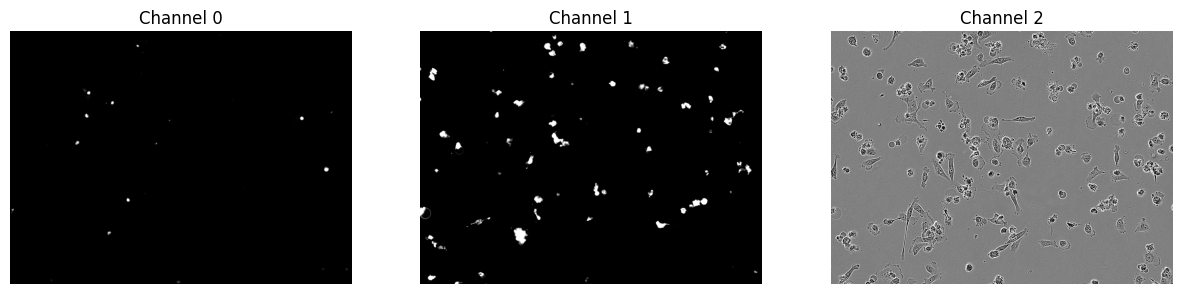

In [56]:
image = imread(r"e:\Marcus\combined_stack.tif")
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))
for i in range(3):
    ax[i].imshow(image[10,i,:,:], cmap = "gray")
    ax[i].set_title(f"Channel {i}")
    ax[i].axis('off')

In [57]:
masks_stack = cellpose_live_segmentation(image[:,-1,:,:], to_plot=True, to_save=True)



Auto-detecting cell diameter from first frame...
  Estimated diameter: 48.1 pixels
Segmenting 25 frames with Cellpose cyto3 (GPU)...


Cellpose segmentation: 100%|██████████| 25/25 [00:28<00:00,  1.14s/it]


✓ Segmentation complete!
  Diameter used: 48.1 pixels
  First 5 frames: [np.uint16(199), np.uint16(211), np.uint16(209), np.uint16(211), np.uint16(208)] cells
  Total cells detected: 5360


In [58]:
masks_path = Path("./masks_stack.tiff")
tiff.imwrite(str(masks_path), masks_stack.astype(np.uint16))
print(f"Saved masks stack to: {masks_path.resolve()}")

Saved masks stack to: C:\Users\isobe\Dropbox (Personal)\Python\image_quantification\Annexin_V_Incucyte_Analysis\masks_stack.tiff


In [ ]:
# # === Ultrack linker: unlinked labels -> linked labels (cross-platform) ===
# import os, sys, glob, platform
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import mip
# from ultrack import MainConfig, Tracker
# ############WORKS BUT NOT GREAT #########
# def _find_cbc_library():
#     """Return CBC shared library path for python-mip on Windows/macOS/Linux, or None if not found."""
#     system = platform.system()
#     if system == "Windows":
#         lib_patterns = ["CbcSolver*.dll", "libCbc*.dll", "Cbc*.dll"]
#         env_dirs = [Path(sys.prefix) / "Library" / "bin", Path(sys.prefix) / "bin"]
#     elif system == "Darwin":
#         lib_patterns = ["libCbcSolver*.dylib", "libCbc*.dylib"]
#         env_dirs = [Path(sys.prefix) / "lib"]
#     else:
#         lib_patterns = ["libCbcSolver*.so", "libCbc*.so"]
#         env_dirs = [Path(sys.prefix) / "lib"]

#     cbc_candidates = []
#     for env_dir in env_dirs:
#         if env_dir.exists():
#             for pattern in lib_patterns:
#                 cbc_candidates.extend(glob.glob(str(env_dir / pattern)))

#     return cbc_candidates[0] if cbc_candidates else None

# def _can_init_solver(solver_const):
#     """Return True if python-mip can initialize the requested solver in current env."""
#     try:
#         model = mip.Model(solver_name=solver_const)
#         _ = model.add_var(name="x", lb=0.0)
#         model.objective = 0.0
#         model.optimize(max_seconds=0.01)
#         return True
#     except Exception:
#         return False

# def _tracks_to_linked_labels(labels, tracks_df):
#     """Map per-frame segmentation labels to persistent track IDs."""
#     labels = np.asarray(labels)
#     if labels.ndim == 2:
#         labels = labels[None, ...]

#     required = {"track_id", "t", "y", "x"}
#     if not required.issubset(tracks_df.columns):
#         raise ValueError(f"tracks_df must contain {required}. Got {tracks_df.columns.tolist()}")

#     T, H, W = labels.shape
#     linked = np.zeros((T, H, W), dtype=np.uint32)

#     for t in range(T):
#         frame_tracks = tracks_df[tracks_df["t"].astype(int) == t]
#         if frame_tracks.empty or labels[t].max() == 0:
#             continue

#         yy = np.clip(np.round(frame_tracks["y"]).astype(int), 0, H - 1)
#         xx = np.clip(np.round(frame_tracks["x"]).astype(int), 0, W - 1)

#         seg_label_at_track = labels[t][yy, xx]
#         frame_tracks = frame_tracks.copy()
#         frame_tracks["seg_label"] = seg_label_at_track
#         frame_tracks = frame_tracks[frame_tracks["seg_label"] > 0]
#         if frame_tracks.empty:
#             continue

#         vote = (frame_tracks
#                 .groupby(["seg_label", "track_id"])
#                 .size()
#                 .reset_index(name="n"))
#         best = vote.sort_values(["seg_label", "n"], ascending=[True, False]).drop_duplicates("seg_label")

#         mapped = np.zeros_like(labels[t], dtype=np.uint32)
#         for seg_label, track_id in zip(best["seg_label"].values, best["track_id"].values):
#             mapped[labels[t] == seg_label] = np.uint32(track_id)

#         linked[t] = mapped

#     return linked

# def _configure_tracking_params(cfg, max_distance=None, division_weight=None, disappearance_weight=None, appear_weight=None):
#     """Set tracking params with compatibility across ultrack versions."""
#     tc = cfg.tracking_config
#     fields = set(tc.__fields__.keys())

#     distance_field_used = None
#     if max_distance is not None and "max_distance" in fields:
#         tc.max_distance = max_distance
#         distance_field_used = "max_distance"

#     if division_weight is not None and "division_weight" in fields:
#         tc.division_weight = division_weight
#     if disappearance_weight is not None and "disappear_weight" in fields:
#         tc.disappear_weight = disappearance_weight
#     if appear_weight is not None and "appear_weight" in fields:
#         tc.appear_weight = appear_weight

#     return distance_field_used

# def _run_tracker(cfg, labels):
#     tracker = Tracker(cfg)
#     tracker.track(labels=labels, overwrite="all")
#     tracks_df, _ = tracker.to_tracks_layer()
#     return tracks_df

# def link_labels_ultrack(
#     labels,
#     output_dir="./tracking_results",
#     max_distance=None,
#     division_weight=None,
#     disappearance_weight=None,
#     appear_weight=None,
#     min_area=20,
#     save_tracks_csv=True,
#     tracks_csv_name="tracks_cellpose.csv",
#     solver_preference="auto",
# ):
#     """Link an unlinked label stack with Ultrack and return linked labels + tracks."""
#     labels = np.asarray(labels)
#     if labels.ndim == 2:
#         labels = labels[None, ...]
#     if labels.ndim != 3:
#         raise ValueError(f"labels must be 2D or 3D. Got shape {labels.shape}")
#     if labels.dtype not in (np.uint16, np.uint32, np.int32, np.int16):
#         labels = labels.astype(np.uint16)

#     output_dir = Path(output_dir)
#     output_dir.mkdir(parents=True, exist_ok=True)

#     pref = str(solver_preference).upper()
#     cbc_library = _find_cbc_library()
#     if cbc_library is not None:
#         os.environ["PMIP_CBC_LIBRARY"] = cbc_library

#     if pref == "CBC":
#         if not _can_init_solver(mip.CBC):
#             raise RuntimeError("CBC solver requested but python-mip could not initialize CBC in this environment.")
#         solver_const = mip.CBC
#         solver_name = "CBC"
#     elif pref == "HIGHS":
#         if not _can_init_solver(mip.HIGHS):
#             raise RuntimeError("HiGHS solver requested but python-mip could not initialize it. Use solver_preference='CBC'.")
#         solver_const = mip.HIGHS
#         solver_name = "HIGHS"
#     else:
#         if _can_init_solver(mip.CBC):
#             solver_const = mip.CBC
#             solver_name = "CBC"
#         elif _can_init_solver(mip.HIGHS):
#             solver_const = mip.HIGHS
#             solver_name = "HIGHS"
#         else:
#             raise RuntimeError("No usable MILP solver found for python-mip.")

#     cfg = MainConfig(output_path=str(output_dir), ndim=2, time_lapse=True)
#     cfg.segmentation_config.n_workers = 1
#     if hasattr(cfg.segmentation_config, "min_area") and min_area is not None:
#         cfg.segmentation_config.min_area = int(min_area)
#     distance_field_used = _configure_tracking_params(
#         cfg, max_distance, division_weight, disappearance_weight, appear_weight
#     )
#     cfg.tracking_config.solver_name = solver_const

#     print(f"Using solver: {solver_name}")
#     if distance_field_used is not None:
#         print(f"Tracking distance parameter mapped to: {distance_field_used}")

#     try:
#         tracks_df = _run_tracker(cfg, labels)
#     except ValueError as e:
#         if "edges solution is empty" not in str(e).lower():
#             raise
#         print("Ultrack found no edges with current settings; retrying with relaxed min_area=1 and default tracking weights...")
#         cfg_retry = MainConfig(output_path=str(output_dir), ndim=2, time_lapse=True)
#         cfg_retry.segmentation_config.n_workers = 1
#         if hasattr(cfg_retry.segmentation_config, "min_area"):
#             cfg_retry.segmentation_config.min_area = 1
#         cfg_retry.tracking_config.solver_name = solver_const
#         tracks_df = _run_tracker(cfg_retry, labels)

#     linked_labels = _tracks_to_linked_labels(labels, tracks_df)

#     if save_tracks_csv:
#         csv_path = output_dir / tracks_csv_name
#         tracks_df.to_csv(csv_path, index=False)

#     return linked_labels, tracks_df

# # Example usage
# linked_labels, tracks_df = link_labels_ultrack(
#     masks_stack,
#     output_dir="./tracking_results",
#     solver_preference="auto",
#     min_area=20
#     )
# print(f"Linked labels shape: {linked_labels.shape}, dtype: {linked_labels.dtype}")
# print(f"Tracks: {len(tracks_df)} detections, {tracks_df['track_id'].nunique() if 'track_id' in tracks_df.columns else 'unknown'} track IDs")
# display(tracks_df.head(10))

Using solver: CBC


Linking nodes.: 100%|██████████| 24/24 [00:00<00:00, 30.18it/s]


Using Coin-OR Branch and Cut solver
Solving ILP batch 0
Constructing ILP ...
Solving ILP ...
Saving solution ...
Done!
Linked labels shape: (25, 1040, 1408), dtype: uint32
Tracks: 2557 detections, 930 track IDs


,track_id,t,y,x,id,parent_track_id,parent_id
id,,,,,,,
1000002,1,0,24.0,648.0,1000002,-1,-1
2000023,1,1,11.0,643.0,2000023,-1,1000002
3000014,1,2,12.0,653.0,3000014,-1,2000023
1000003,2,0,35.0,693.0,1000003,-1,-1
2000011,2,1,30.0,700.0,2000011,-1,1000003
1000005,3,0,91.0,700.0,1000005,-1,-1
2000014,3,1,95.0,706.0,2000014,-1,1000005
1000008,4,0,120.0,587.0,1000008,-1,-1
2000017,4,1,122.0,601.0,2000017,-1,1000008


In [ ]:
# === TrackMate headless on label image `masks_stack` ===
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff
import imagej
from imagej import Mode
import scyjava as sj

DEBUG_TRACKMATE = True

# Ensure a JVM is available (Windows-friendly): prefer jdk4py if JAVA_HOME is unset
if not os.environ.get("JAVA_HOME"):
    try:
        import jdk4py
        os.environ["JAVA_HOME"] = str(jdk4py.JAVA_HOME)
        java_bin = Path(jdk4py.JAVA_HOME) / "bin"
        os.environ["PATH"] = str(java_bin) + os.pathsep + os.environ.get("PATH", "")
        print(f"JAVA_HOME set from jdk4py: {os.environ['JAVA_HOME']}")
    except Exception as e:
        print(f"Could not auto-configure JAVA_HOME from jdk4py: {e}")

# 1) User settings
TRACKMATE_WORKDIR = Path("./trackmate_headless")
TRACKMATE_WORKDIR.mkdir(parents=True, exist_ok=True)

# Tracker settings requested
TARGET_CHANNEL = 1
SIMPLIFY_CONTOURS = False
INITIAL_SEARCH_RADIUS = 30.0
SEARCH_RADIUS = 150.0
ALLOW_TRACK_SPLITTING = False
ALLOW_TRACK_MERGING = False

# 2) Prepare label-image input stack for TrackMate (T,Y,X)
if "masks_stack" not in globals():
    raise ValueError("`masks_stack` is required in memory.")

label_stack = np.asarray(masks_stack)
if label_stack.ndim == 2:
    label_stack = label_stack[np.newaxis, :, :]
if label_stack.ndim != 3:
    raise ValueError(f"`masks_stack` must be 2D or 3D (T,Y,X). Got shape {label_stack.shape}")

if DEBUG_TRACKMATE:
    print("=== Input label-stack diagnostics ===")
    print(f"Shape (T,Y,X): {label_stack.shape}")
    print(f"Dtype: {label_stack.dtype}")
    print(f"Global min/max: {label_stack.min()} / {label_stack.max()}")

    frame_rows = []
    for t in range(label_stack.shape[0]):
        frame = label_stack[t]
        labels = np.unique(frame)
        n_labels = int(np.sum(labels > 0))
        nonzero_px = int(np.count_nonzero(frame))
        frame_rows.append({"t": t, "n_labels": n_labels, "nonzero_px": nonzero_px})

    frame_diag_df = pd.DataFrame(frame_rows)
    print("Per-frame labels summary (first 10):")
    display(frame_diag_df.head(10))
    print(f"Frames with >=1 label: {(frame_diag_df['n_labels'] > 0).sum()} / {len(frame_diag_df)}")
    print(f"Mean labels/frame: {frame_diag_df['n_labels'].mean():.2f}")

trackmate_input_tif = TRACKMATE_WORKDIR / "trackmate_labels_input.tif"
tiff.imwrite(str(trackmate_input_tif), label_stack.astype(np.uint16))
print(f"Saved TrackMate label input stack: {trackmate_input_tif.resolve()}")

Saved TrackMate label input stack: C:\Users\isobe\Dropbox (Personal)\Python\image_quantification\Annexin_V_Incucyte_Analysis\trackmate_headless\trackmate_labels_input.tif


<Image layer 'TrackMate Input Labels' at 0x2546b07ada0>

In [68]:

# 3) Initialize Fiji headless through PyImageJ
print("Initializing PyImageJ headless (first run may download Fiji components)...")
ij = imagej.init("sc.fiji:fiji", mode=Mode.HEADLESS, add_legacy=True)

# Java imports
IJ = sj.jimport("ij.IJ")
HashMap = sj.jimport("java.util.HashMap")
ArrayList = sj.jimport("java.util.ArrayList")
Collections = sj.jimport("java.util.Collections")
Comparator = sj.jimport("java.util.Comparator")
Integer = sj.jimport("java.lang.Integer")
Double = sj.jimport("java.lang.Double")

Model = sj.jimport("fiji.plugin.trackmate.Model")
Settings = sj.jimport("fiji.plugin.trackmate.Settings")
TrackMate = sj.jimport("fiji.plugin.trackmate.TrackMate")
Logger = sj.jimport("fiji.plugin.trackmate.Logger")

LabelImageDetectorFactory = sj.jimport("fiji.plugin.trackmate.detection.LabelImageDetectorFactory")
AdvancedKalmanTrackerFactory = sj.jimport("fiji.plugin.trackmate.tracking.kalman.AdvancedKalmanTrackerFactory")

# 4) Run TrackMate with label-image detector + advanced Kalman tracker
imp = IJ.openImage(str(trackmate_input_tif))
if imp is None:
    raise RuntimeError(f"Could not open image: {trackmate_input_tif}")

model = Model()
model.setLogger(Logger.IJ_LOGGER)

settings = Settings(imp)
settings.detectorFactory = LabelImageDetectorFactory()
detector_settings = HashMap()
detector_settings.put("TARGET_CHANNEL", Integer.valueOf(int(TARGET_CHANNEL)))
detector_settings.put("SIMPLIFY_CONTOURS", bool(SIMPLIFY_CONTOURS))
settings.detectorSettings = detector_settings

settings.trackerFactory = AdvancedKalmanTrackerFactory()
tracker_settings = HashMap(settings.trackerFactory.getDefaultSettings())
tracker_settings.put("KALMAN_SEARCH_RADIUS", Double.valueOf(float(SEARCH_RADIUS)))
tracker_settings.put("LINKING_MAX_DISTANCE", Double.valueOf(float(INITIAL_SEARCH_RADIUS)))
tracker_settings.put("ALLOW_TRACK_SPLITTING", ALLOW_TRACK_SPLITTING)
tracker_settings.put("ALLOW_TRACK_MERGING", ALLOW_TRACK_MERGING)

# Feature penalties: x, y, area = 1
feature_penalties = HashMap()
feature_penalties.put("POSITION_X", Double.valueOf(1.0))
feature_penalties.put("POSITION_Y", Double.valueOf(1.0))
feature_penalties.put("AREA", Double.valueOf(1.0))
tracker_settings.put("LINKING_FEATURE_PENALTIES", feature_penalties)
tracker_settings.put("GAP_CLOSING_FEATURE_PENALTIES", feature_penalties)

settings.trackerSettings = tracker_settings
settings.addAllAnalyzers()

trackmate = TrackMate(model, settings)
if not trackmate.checkInput():
    raise RuntimeError(f"TrackMate input error: {trackmate.getErrorMessage()}")
if not trackmate.process():
    raise RuntimeError(f"TrackMate process error: {trackmate.getErrorMessage()}")

# 5) Export tracks to DataFrame + CSV
tm = model.getTrackModel()
rows = []
for track_id in tm.trackIDs(True):
    spots = ArrayList(tm.trackSpots(track_id))

    class FrameComparator(Comparator):
        def compare(self, a, b):
            fa = float(a.getFeature("FRAME"))
            fb = float(b.getFeature("FRAME"))
            return -1 if fa < fb else (1 if fa > fb else 0)

    Collections.sort(spots, FrameComparator())

    for spot in spots:
        t = int(float(spot.getFeature("FRAME")))
        x = float(spot.getFeature("POSITION_X"))
        y = float(spot.getFeature("POSITION_Y"))
        q = float(spot.getFeature("QUALITY"))
        rows.append({"track_id": int(track_id), "t": t, "y": y, "x": x, "quality": q})

trackmate_tracks_df = pd.DataFrame(rows, columns=["track_id", "t", "y", "x", "quality"])
tracks_csv = TRACKMATE_WORKDIR / "trackmate_tracks.csv"
trackmate_tracks_df.to_csv(tracks_csv, index=False)

print(f"Saved TrackMate CSV: {tracks_csv.resolve()}")
print(f"Loaded TrackMate tracks: {len(trackmate_tracks_df)} rows")
display(trackmate_tracks_df.head(10))

Initializing PyImageJ headless (first run may download Fiji components)...
Saved TrackMate CSV: C:\Users\isobe\Dropbox (Personal)\Python\image_quantification\Annexin_V_Incucyte_Analysis\trackmate_headless\trackmate_tracks.csv
Loaded TrackMate tracks: 0 rows


,track_id,t,y,x,quality


In [ ]:
# This cell is intentionally kept empty.
# Run Cell 7 for TrackMate label-image + advanced Kalman tracking.

In [64]:
# Optional: quick Napari overlay of TrackMate tracks
if "trackmate_tracks_df" not in globals():
    raise ValueError("Run Cell 7 (TrackMate headless) first.")

viewer = napari.Viewer()
viewer.add_image(image[:, -1, :, :], name="Raw Image", colormap="gray")

required_cols = ["track_id", "t", "y", "x"]
missing_cols = [c for c in required_cols if c not in trackmate_tracks_df.columns]
if missing_cols:
    raise ValueError(f"`trackmate_tracks_df` missing columns: {missing_cols}")

if len(trackmate_tracks_df) == 0:
    print("No tracks to display (trackmate_tracks_df is empty).")
else:
    tracks_for_napari = trackmate_tracks_df[required_cols].to_numpy()
    viewer.add_tracks(tracks_for_napari, name="TrackMate tracks")
    print(f"Displayed {len(tracks_for_napari)} track points in napari.")

No tracks to display (trackmate_tracks_df is empty).


<Labels layer 'Cellpose Segmentation' at 0x25463b8ba90>